# ML Assignment- Hurricane Forecasting with Multi-Layer Perceptron

 



#  Loading Libraries and Data Cleaning

In [1]:
import numpy
import pandas as pd
import torch
import torch.nn
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from copy import deepcopy
from pathlib import Path
import pickle
import random
import time
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


Merging all the datasets from all 6 folders

In [2]:
def load_all_data(data_path):

    data_path = Path(data_path)

    # mapping folder names 
    variables = {
        'Rainf_tavg': 'rain',
        'Wind_f_inst': 'wind_speed',
        'Psurf_f_inst': 'pressure',
        'Wind_dir_p1000': 'wind_dir',
        'SWdown_f_tavg': 'sw_radiation',
        'LWdown_f_tavg': 'lw_radiation'
    }

    all_data = {}
    print("Loading the datasets")
    for folder_name in variables:
        folder_path = data_path / folder_name
        if not folder_path.exists():
            print("Folder not found:", folder_name)
            continue
        csv_files = sorted(folder_path.rglob("*.csv"))
        if len(csv_files) == 0:
            print("No CSV files in:", folder_name)
            continue
        df_list = []
        for i, file in enumerate(csv_files):
            df = pd.read_csv(file)
            df_list.append(df)
        combined = pd.concat(df_list, ignore_index=True)
        var_name = variables[folder_name]
        all_data[var_name] = combined
        print(var_name, "loaded with shape:", combined.shape)
    return all_data


def merge_datasets(all_data):
    base_cols = ['longitude', 'latitude', 'year', 'month', 'day']
    merged = None
    print("\nMerging datasets")
    for var in all_data:
        df = all_data[var]
        new_cols = {}
        for col in df.columns:
            if col.startswith("data_hour_"):
                new_cols[col] = var + "_" + col
        df = df.rename(columns=new_cols)
        if merged is None:
            merged = df
            print("Starting with:", var)
        else:
            print("Merging:", var)
            merged = merged.merge(df, on=base_cols, how='inner')
    print("Final shape:", merged.shape)
    return merged


def save_merged_dataset(df, filename="merged_hurricane_data.csv"):
    df.to_csv(filename, index=False)
    print("Megred dataset:", filename)
    print("Shape:", df.shape)
    return filename

def load_merged_dataset(filename="merged_hurricane_data.csv"):
    print("Loading merged file")
    df = pd.read_csv(filename)
    print("Loaded. Shape:", df.shape)
    return df


if __name__ == "__main__":
    data_path = "/Users/lata.bharati/Documents/Hurricane_Data"
    data = load_all_data(data_path)
    merged = merge_datasets(data)
    save_merged_dataset(merged)


Loading the datasets
rain loaded with shape: (14749707, 13)
wind_speed loaded with shape: (14895900, 13)
pressure loaded with shape: (14895900, 13)
wind_dir loaded with shape: (32672049, 13)
sw_radiation loaded with shape: (14895900, 13)
lw_radiation loaded with shape: (14895900, 13)

Merging datasets
Starting with: rain
Merging: wind_speed
Merging: pressure
Merging: wind_dir
Merging: sw_radiation
Merging: lw_radiation
Final shape: (1404783, 53)
Megred dataset: merged_hurricane_data.csv
Shape: (1404783, 53)


In [3]:
# Path of merged dataset
data_file_full_path = "/Users/lata.bharati/Downloads/merged_hurricane_data.csv"

In [4]:
data_df = pd.read_csv(data_file_full_path)
print(f"Dataset loaded successfully!")
print(f"Shape: {data_df.shape[0]:,} rows × {data_df.shape[1]} columns")

Dataset loaded successfully!
Shape: 1,404,783 rows × 53 columns


In [5]:
total_nulls = data_df.isna().sum().sum()
print(f"Total null values: {total_nulls:,}")

if total_nulls > 0:
    print(f"Columns with nulls:")
    null_cols = data_df.isnull().sum()
    for col, count in null_cols[null_cols > 0].items():
        pct = 100 * count / len(data_df)
        print(f"{col}: {count:,} ({pct:.1f}%)")
    original_size = data_df.shape[0]


Total null values: 2,436,922
Columns with nulls:
wind_dir_data_hour_0: 279,877 (19.9%)
wind_dir_data_hour_3: 283,901 (20.2%)
wind_dir_data_hour_6: 318,104 (22.6%)
wind_dir_data_hour_9: 316,254 (22.5%)
wind_dir_data_hour_12: 285,139 (20.3%)
wind_dir_data_hour_15: 290,984 (20.7%)
wind_dir_data_hour_18: 335,934 (23.9%)
wind_dir_data_hour_21: 326,729 (23.3%)


In [6]:
# Replacing wind direction nulls with 0 [calm conditions = no direction]
wind_dir_cols = [col for col in data_df.columns if 'wind_dir' in col]
for col in wind_dir_cols:
    data_df[col].fillna(0, inplace=True)
print(f"Rows kept: {len(data_df):,} (100%)")
print(f"Remaining nulls: {data_df.isnull().sum().sum()}")

Rows kept: 1,404,783 (100%)
Remaining nulls: 0


# Features and Labels

In [7]:
def create_features_labels(df, lookback_days=7, forecast_days=7):

    print(f"Creating features and labels...")
    print(f"Lookback window: {lookback_days} days")
    print(f"Forecast horizon: {forecast_days} days ahead")
    
    df = data_df.copy()
    
    # Date column
    df["date"] = pd.to_datetime(df[["year", "month", "day"]])
    df["day_of_year"] = df["date"].dt.dayofyear
    
    # Sort by location and date
    df = df.sort_values(["longitude", "latitude", "date"]).reset_index(drop=True)
    
    features_list = []
    labels_list = []
    dates_list = []
    skipped_not_7_days = 0
    grouped = df.groupby(["longitude", "latitude"])
    total_locations = len(grouped)
    print(f"Processing {total_locations:,} unique locations...")
    
    processed = 0
    for (lon, lat), group in grouped:
        processed += 1
        
        if processed % 500 == 0:
            print(f"Progress: {processed:,}/{total_locations:,} ({100*processed/total_locations:.1f}%)")
        
        group = group.sort_values("date").reset_index(drop=True)
        
        for i in range(len(group) - lookback_days - forecast_days + 1):
            
            # 7-day historical input window
            window = group.iloc[i:i + lookback_days]
            
            # Target day(7 days ahead)
            target_idx = i + lookback_days + forecast_days - 1
            target = group.iloc[target_idx]
            
            # Verify 7 days gap
            last_input_date = window.iloc[-1]["date"]
            target_date = target["date"]
            
            if (target_date - last_input_date).days != forecast_days:
                skipped_not_7_days += 1
                continue
            
            feature_vector = []
            
            # For each day in the 7-day window
            for _, row in window.iterrows():
                
                # Temporal features (3)
                feature_vector.extend([
                    row["day_of_year"],
                    row["month"],
                    row["day"]
                ])
                # Spatial features (2)
                feature_vector.extend([lon, lat])
                # Meteorological features (4 variables × 10 = 40)
                for var in ["rain", "wind_speed", "pressure", "wind_dir"]:
                    # 8 hourly measurements
                    hour_values = [
                        row[f"{var}_data_hour_{h}"]
                        for h in [0, 3, 6, 9, 12, 15, 18, 21]
                    ]
                    feature_vector.extend(hour_values)  # 8 values
                    feature_vector.append(numpy.mean(hour_values))  # mean
                    feature_vector.append(numpy.std(hour_values))   # std
            
            # Create labels (4 - daily average)
            rain_target = numpy.mean([
                target[f"rain_data_hour_{h}"]
                for h in [0, 3, 6, 9, 12, 15, 18, 21]
            ])
            
            wind_speed_target = numpy.mean([
                target[f"wind_speed_data_hour_{h}"]
                for h in [0, 3, 6, 9, 12, 15, 18, 21]
            ])
            
            pressure_target = numpy.mean([
                target[f"pressure_data_hour_{h}"]
                for h in [0, 3, 6, 9, 12, 15, 18, 21]
            ])
            
            # Wind direction
            wind_dirs = [
                target[f"wind_dir_data_hour_{h}"]
                for h in [0, 3, 6, 9, 12, 15, 18, 21]
            ]
            
            wind_dir_rad = numpy.deg2rad(wind_dirs)
            wind_dir_target = numpy.rad2deg(
                numpy.arctan2(
                    numpy.mean(numpy.sin(wind_dir_rad)),
                    numpy.mean(numpy.cos(wind_dir_rad))
                )
            )
            
            if wind_dir_target < 0:
                wind_dir_target += 360
            
            labels = [
                rain_target,
                wind_speed_target,
                wind_dir_target,
                pressure_target
            ]
            
            features_list.append(feature_vector)
            labels_list.append(labels)
            dates_list.append(target_date)
 
    X = numpy.array(features_list)
    y = numpy.array(labels_list)
    sample_dates = numpy.array(dates_list)
    
    print(f"Feature engineering complete!")
    print(f"Features shape: {X.shape}")
    print(f"Labels shape: {y.shape}")
    print(f"Features per sample: {X.shape[1]}")
    print(f"Skipped samples (not exactly 7 days): {skipped_not_7_days:,}")
    
    print(f"Feature breakdown per day:")
    print(f"Temporal: 3 (day_of_year, month, day)")
    print(f"Spatial: 2 (longitude, latitude)")
    print(f"Meteorological: 40 (4 vars × 10 each)")
    print(f"Total per day: 45")
    print(f"Total for 7 days: {X.shape[1]}")
    
    return X, y, sample_dates

feats, labels, sample_dates = create_features_labels(
    data_df,
    lookback_days=7,
    forecast_days=7
)

Creating features and labels...
Lookback window: 7 days
Forecast horizon: 7 days ahead
Processing 5,147 unique locations...
Progress: 500/5,147 (9.7%)
Progress: 1,000/5,147 (19.4%)
Progress: 1,500/5,147 (29.1%)
Progress: 2,000/5,147 (38.9%)
Progress: 2,500/5,147 (48.6%)
Progress: 3,000/5,147 (58.3%)
Progress: 3,500/5,147 (68.0%)
Progress: 4,000/5,147 (77.7%)
Progress: 4,500/5,147 (87.4%)
Progress: 5,000/5,147 (97.1%)
Feature engineering complete!
Features shape: (582353, 315)
Labels shape: (582353, 4)
Features per sample: 315
Skipped samples (not exactly 7 days): 762,260
Feature breakdown per day:
Temporal: 3 (day_of_year, month, day)
Spatial: 2 (longitude, latitude)
Meteorological: 40 (4 vars × 10 each)
Total per day: 45
Total for 7 days: 315


In [8]:
# Sort by date 
sort_idx = numpy.argsort(sample_dates)
feats_sorted = feats[sort_idx]
labels_sorted = labels[sort_idx]
dates_sorted = sample_dates[sort_idx]
print(f"Date range: {dates_sorted[0]} to {dates_sorted[-1]}")

# Indices for all samples
all_ids = numpy.arange(0, feats_sorted.shape[0])

# Split points (70% train, 15% val, 15% test)
train_size = int(0.70 * len(all_ids))
val_size = int(0.15 * len(all_ids))

# Split indices chronologically
train_set_ids = all_ids[:train_size]
val_set_ids = all_ids[train_size:train_size + val_size]
test_set_ids = all_ids[train_size + val_size:]

print(f"Total samples: {len(all_ids):,}")
print(f"Train samples: {len(train_set_ids):,} ({100*len(train_set_ids)/len(all_ids):.1f}%)")
print(f"Val samples: {len(val_set_ids):,} ({100*len(val_set_ids)/len(all_ids):.1f}%)")
print(f"Test samples: {len(test_set_ids):,} ({100*len(test_set_ids)/len(all_ids):.1f}%)")

# Extract train data and labels
train_data = feats_sorted[train_set_ids, :]
train_labels = labels_sorted[train_set_ids]
train_dates = dates_sorted[train_set_ids]

# Extract validation data and labels
val_data = feats_sorted[val_set_ids, :]
val_labels = labels_sorted[val_set_ids]
val_dates = dates_sorted[val_set_ids]

# Extract test data and labels
test_data = feats_sorted[test_set_ids, :]
test_labels = labels_sorted[test_set_ids]
test_dates = dates_sorted[test_set_ids]

print(f"TRAIN SET:")
print(f"Shape: {train_data.shape}")
print(f"Date range: {train_dates[0]} to {train_dates[-1]}")

print(f"VALIDATION SET:")
print(f"Shape: {val_data.shape}")
print(f"Date range: {val_dates[0]} to {val_dates[-1]}")

print(f"TEST SET:")
print(f"Shape: {test_data.shape}")
print(f"Date range: {test_dates[0]} to {test_dates[-1]}")

Date range: 2023-01-15 00:00:00 to 2025-08-30 00:00:00
Total samples: 582,353
Train samples: 407,647 (70.0%)
Val samples: 87,352 (15.0%)
Test samples: 87,354 (15.0%)
TRAIN SET:
Shape: (407647, 315)
Date range: 2023-01-15 00:00:00 to 2024-12-23 00:00:00
VALIDATION SET:
Shape: (87352, 315)
Date range: 2024-12-23 00:00:00 to 2025-04-04 00:00:00
TEST SET:
Shape: (87354, 315)
Date range: 2025-04-04 00:00:00 to 2025-08-30 00:00:00


# Scaling the input data

In [9]:
# Create scalers
feature_scaler = StandardScaler()
label_scaler = StandardScaler()

# Fit and transform training data
scaled_train_data = feature_scaler.fit_transform(train_data)
scaled_train_labels = label_scaler.fit_transform(train_labels)

# Transform validation and test data
scaled_val_data = feature_scaler.transform(val_data)
scaled_val_labels = label_scaler.transform(val_labels)

scaled_test_data = feature_scaler.transform(test_data)
scaled_test_labels = label_scaler.transform(test_labels)

# Results after scaling
print(f"Train: {scaled_train_data.shape}, mean={scaled_train_data.mean():.3f}, std={scaled_train_data.std():.3f}")
print(f"Val: {scaled_val_data.shape}")
print(f"Test: {scaled_test_data.shape}")

Train: (407647, 315), mean=0.000, std=1.000
Val: (87352, 315)
Test: (87354, 315)


# Train and Evaluate Multilayer Perceptron

In [10]:
random_seed = 372
random.seed(random_seed)
numpy.random.seed(random_seed)
torch.manual_seed(random_seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(scaled_train_data).to(device)
y_train_tensor = torch.FloatTensor(scaled_train_labels).to(device)

X_val_tensor = torch.FloatTensor(scaled_val_data).to(device)
y_val_tensor = torch.FloatTensor(scaled_val_labels).to(device)

X_test_tensor = torch.FloatTensor(scaled_test_data).to(device)
y_test_tensor = torch.FloatTensor(scaled_test_labels).to(device)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# 4-layer MLP 
class MyMLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(MyMLP, self).__init__()
        self.fc1 = nn.Linear(in_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, out_dim)
        self.dropout = nn.Dropout(0.3) 
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

# Create model
in_dim = 315  # Number of features
out_dim = 4   # Number of labels (rain, wind_speed, wind_dir, pressure)

model = MyMLP(in_dim, out_dim).to(device)

print("Model architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training parameters
num_epochs = 300
patience = 50
best_val_loss = float('inf')
patience_counter = 0

start_time = time.time()

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Print progress every 50 epochs
    if (epoch + 1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(best_model_state)

training_time = time.time() - start_time

print(f"Training complete!")
print(f"Time: {training_time:.2f} seconds")
print(f"Total epochs: {epoch+1}")
print(f"Best validation loss: {best_val_loss:.6f}")

model.eval()
with torch.no_grad():
    train_pred_scaled = model(X_train_tensor).cpu().numpy()
    val_pred_scaled = model(X_val_tensor).cpu().numpy()
    test_pred_scaled = model(X_test_tensor).cpu().numpy()

# Inverse transform to original scale
train_pred_original = label_scaler.inverse_transform(train_pred_scaled)
train_actual_original = label_scaler.inverse_transform(scaled_train_labels)

val_pred_original = label_scaler.inverse_transform(val_pred_scaled)
val_actual_original = label_scaler.inverse_transform(scaled_val_labels)

test_pred_original = label_scaler.inverse_transform(test_pred_scaled)
test_actual_original = label_scaler.inverse_transform(scaled_test_labels)

print("Predictions complete.")

variable_names = ['Rain', 'Wind Speed', 'Wind Direction', 'Pressure']

print("TRAIN SET:")
train_r2 = r2_score(train_actual_original, train_pred_original, multioutput='raw_values')
train_mae = mean_absolute_error(train_actual_original, train_pred_original, multioutput='raw_values')

for i, var in enumerate(variable_names):
    print(f"{var:20s}: R² = {train_r2[i]:.4f}, MAE = {train_mae[i]:.6f}")

print("VALIDATION SET:")
val_r2 = r2_score(val_actual_original, val_pred_original, multioutput='raw_values')
val_mae = mean_absolute_error(val_actual_original, val_pred_original, multioutput='raw_values')

for i, var in enumerate(variable_names):
    print(f"{var:20s}: R² = {val_r2[i]:.4f}, MAE = {val_mae[i]:.6f}")

print("SET:")
test_r2 = r2_score(test_actual_original, test_pred_original, multioutput='raw_values')
test_mae = mean_absolute_error(test_actual_original, test_pred_original, multioutput='raw_values')

for i, var in enumerate(variable_names):
    print(f"{var:20s}: R² = {test_r2[i]:.4f}, MAE = {test_mae[i]:.6f}")

print(f"Best model saved at epoch: {epoch+1-patience_counter}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Average test R²: {test_r2.mean():.4f}")

Using device: cpu
Model architecture:
MyMLP(
  (fc1): Linear(in_features=315, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=4, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Total parameters: 122,308
Epoch [25/300], Train Loss: 0.672961, Val Loss: 0.873474
Epoch [50/300], Train Loss: 0.641376, Val Loss: 0.876361
Early stopping at epoch 51
Training complete!
Time: 166.11 seconds
Total epochs: 51
Best validation loss: 0.853967
Predictions complete.
TRAIN SET:
Rain                : R² = 0.3631, MAE = 0.000021
Wind Speed          : R² = 0.4341, MAE = 1.042378
Wind Direction      : R² = 0.2159, MAE = 78.713743
Pressure            : R² = 0.6690, MAE = 346.083798
VALIDATION SET:
Rain                : R² = 0.1382, MAE = 0.000017
Wind Speed          : R² = 0.1541, MAE = 1.275666
Wind Direction      : R² = 0.0598, MAE = 93.046165
Pressure

In [11]:
# Save the PyTorch model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch+1,
    'best_val_loss': best_val_loss,
}, 'hurricane_mlp_model.pth')
print("Model saved: hurricane_mlp_model.pth")

# Save the scalers
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(feature_scaler, f)
with open('label_scaler.pkl', 'wb') as f:
    pickle.dump(label_scaler, f)
print("Scalers saved: feature_scaler.pkl, label_scaler.pkl")

# Save test predictions to CSV
test_longitudes = test_data[:, 3]
test_latitudes = test_data[:, 4]
test_results_df = pd.DataFrame({
    'date': test_dates,
    'longitude': test_longitudes,
    'latitude': test_latitudes,
    'actual_rain': test_actual_original[:, 0],
    'pred_rain': test_pred_original[:, 0],
    'actual_wind_speed': test_actual_original[:, 1],
    'pred_wind_speed': test_pred_original[:, 1],
    'actual_wind_direction': test_actual_original[:, 2],
    'pred_wind_direction': test_pred_original[:, 2],
    'actual_pressure': test_actual_original[:, 3],
    'pred_pressure': test_pred_original[:, 3]
})

test_results_df.to_csv('test_prediction.csv', index=False)
print("Test predictions saved: test_prediction.csv")
print(f"Rows: {len(test_results_df):,}")

# Performance metrics
metrics_df = pd.DataFrame({
    'Variable': variable_names,
    'Train_R2': train_r2,
    'Train_MAE': train_mae,
    'Val_R2': val_r2,
    'Val_MAE': val_mae,
    'Test_R2': test_r2,
    'Test_MAE': test_mae
})
metrics_df.to_csv('model_metrics.csv', index=False)
print("Metrics saved: model_metrics.csv")

Model saved: hurricane_mlp_model.pth
Scalers saved: feature_scaler.pkl, label_scaler.pkl
Test predictions saved: test_prediction.csv
Rows: 87,354
Metrics saved: model_metrics.csv


# Visualisation

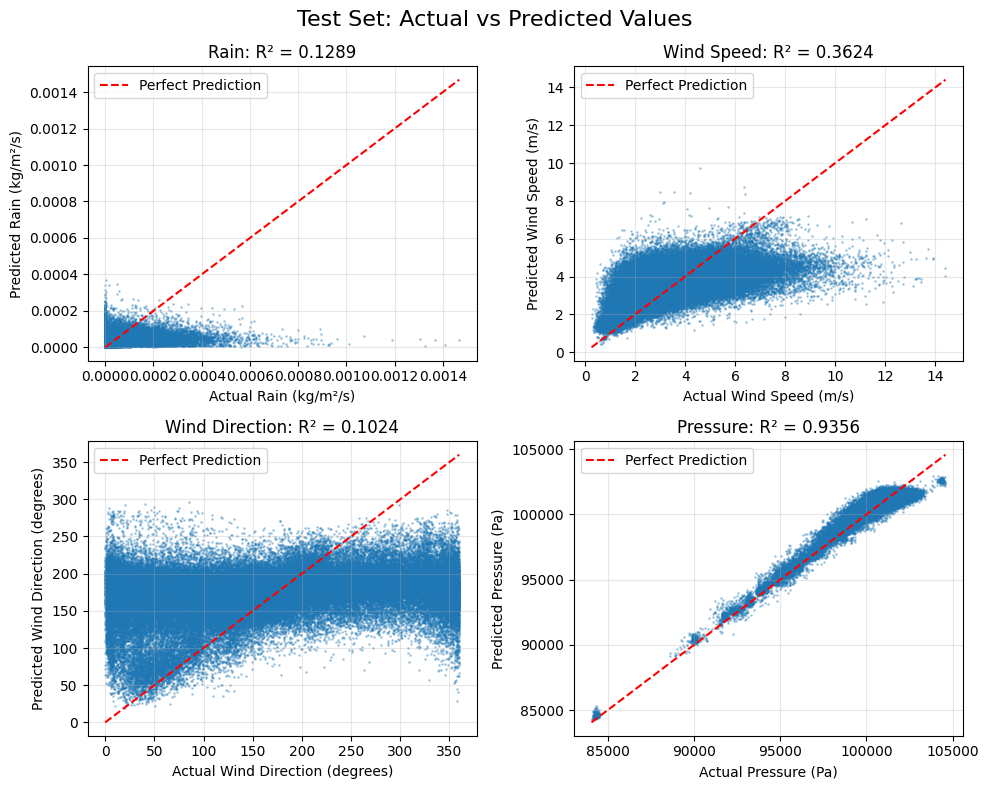

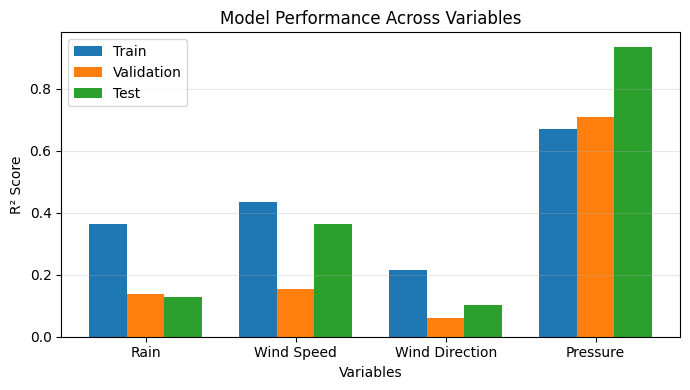

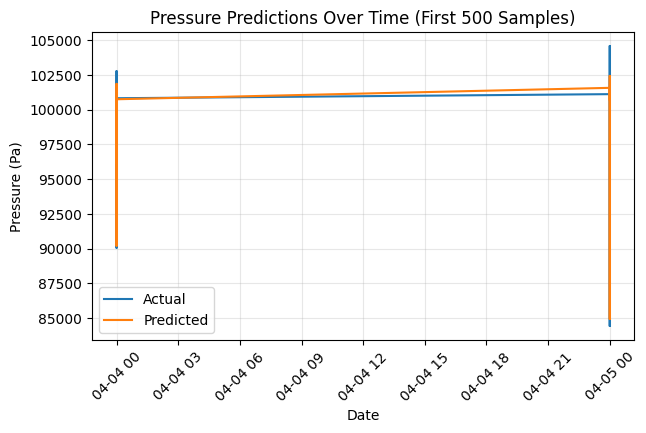

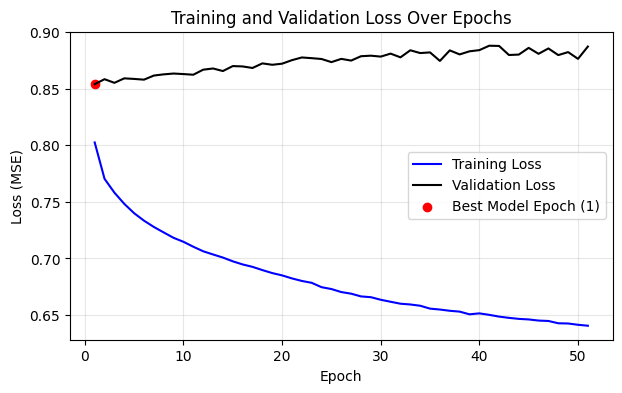

In [12]:
# Variables and units
variables = ["Rain", "Wind Speed", "Wind Direction", "Pressure"]
units = ["kg/m²/s", "m/s", "degrees", "Pa"]

# 1. Actual vs Predicted plots
plt.figure(figsize=(10, 8))
plt.suptitle("Test Set: Actual vs Predicted Values", fontsize=16)

for i in range(4):
    actual = test_actual_original[:, i]
    predicted = test_pred_original[:, i]

    plt.subplot(2, 2, i + 1)
    plt.scatter(actual, predicted, alpha=0.3, s=1)

    min_value = min(actual.min(), predicted.min())
    max_value = max(actual.max(), predicted.max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        "r--",
        label="Perfect Prediction"
    )
    plt.xlabel(f"Actual {variables[i]} ({units[i]})")
    plt.ylabel(f"Predicted {variables[i]} ({units[i]})")
    plt.title(f"{variables[i]}: R² = {test_r2[i]:.4f}")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()


# 2. R² comparison bar chart
x = numpy.arange(len(variables))
width = 0.25

plt.figure(figsize=(7, 4))
plt.bar(x - width, train_r2, width, label="Train")
plt.bar(x, val_r2, width, label="Validation")
plt.bar(x + width, test_r2, width, label="Test")
plt.xlabel("Variables")
plt.ylabel("R² Score")
plt.title("Model Performance Across Variables")
plt.xticks(x, variables)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# 3. Pressure time-series plot
n_samples = min(500, len(test_dates))

plt.figure(figsize=(7, 4))
plt.plot(test_dates[:n_samples], test_actual_original[:n_samples, 3], label="Actual")
plt.plot(test_dates[:n_samples], test_pred_original[:n_samples, 3], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Pressure (Pa)")
plt.title(f"Pressure Predictions Over Time (First {n_samples} Samples)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.savefig("pressure_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()


# 4. Training and validation loss curve
epochs = range(1, len(train_losses) + 1)
best_epoch = val_losses.index(min(val_losses)) + 1

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_losses, color='blue', label="Training Loss")
plt.plot(epochs, val_losses, color='black', label="Validation Loss")
plt.scatter(
    best_epoch,
    min(val_losses), color='red', label=f"Best Model Epoch ({best_epoch})"
)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()